# Modeling Shell and Tube Heat Exchanger Behavior

**Goal:** Build a **simplified** mathematical representation of a shell and tube heat exchanger so that we can (1) predict, (2) understand, and (3) control its behavior.

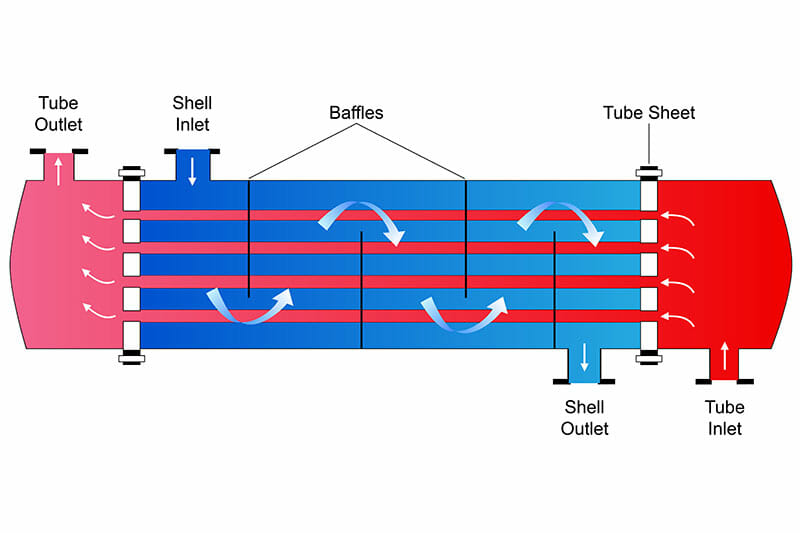   

https://www.torq-n-seal.com/how-do-shell-and-tube-heat-exchangers-work/

### Assumptions 
- Constant fluid properties
- Fully developed flow
- No heat lost to surroundings
- No phase changes

---

### Inputs of the Model

#### Fluid Properties

For both hot and cold streams:

- Density: $\rho$
- Viscosity: $\mu$
- Specific heat: $c_p$
- Thermal conductivity: $k$

#### Operating Conditions

- Hot mass flow rate: $\dot{m}_h$
- Cold mass flow rate: $\dot{m}_c$
- Hot inlet temperature: $T_{h,in}$
- Cold inlet temperature: $T_{c,in}$

#### Geometry (for Shell-and-Tube)

- Tube inner diameter: $D_i$
- Tube outer diameter: $D_o$
- Tube length: $L$
- Number of tubes: $N$
- Wall conductivity: $k_w$

Assumption: We prescribed shell side velocity

---

#### Correlation Choice (Modeling Assumptions)

You must choose:

- Tube-side heat transfer correlation (e.g., Gnielinski)
- Shell-side correlation (e.g., tube-bank crossflow)
- Friction factor model
- Flow arrangement (shell_and_tube, parallel, etc.)

---

## Intermediate Quantities (Computed Internally)

The model computes:

- Velocity
- Reynolds number $Re$
- Prandtl number $Pr$
- Nusselt number $Nu$
- Heat transfer coefficients $h_i, h_o$
- Overall heat transfer coefficient $U$
- $UA$
- Capacity rates $C_h, C_c, C_{min}, C_r$
- Number of transfer units $NTU$
- Effectiveness $\varepsilon$

---

## Outputs of the Model

### Thermal Outputs

- Heat transfer rate: $Q$
- Hot outlet temperature: $T_{h,out}$
- Cold outlet temperature: $T_{c,out}$

### Hydraulic Outputs

- Tube-side pressure drop: $\Delta P_h$
- Shell-side pressure drop: $\Delta P_c$

Pumping power:

$$
\dot{W} = \frac{\dot{m}\,\Delta P}{\rho}
$$

---

$$
\text{Model} :
(\dot{m}_h, \dot{m}_c, T_{h,in}, T_{c,in}, \text{geometry}, \text{properties})
\longrightarrow
(Q, T_{h,out}, T_{c,out}, \Delta P_h, \Delta P_c)
$$

---
## 0. Setup


In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
from dataclasses import dataclass

np.set_printoptions(precision=4, suppress=True)


<Token var=<ContextVar name='format_options' default={'edgeitems': 3, 'threshold': 1000, 'floatmode': 'maxprec', 'precision': 8, 'suppress': False, 'linewidth': 75, 'nanstr': 'nan', 'infstr': 'inf', 'sign': '-', 'formatter': None, 'legacy': 9223372036854775807, 'override_repr': None} at 0x119feb1f0> at 0x119fcad00>

### 1.1 Energy balance
The total rate of heat transfer between the hot and cold fluids $Q$ for a heat exchanger at steady state is given by 

$$
Q = \dot m_h c_{p,h}(T_{h,in}-T_{h,out}) = \dot m_c c_{p,c}(T_{c,out}-T_{c,in})
$$

Where $T$'s are the fluid temperatures at the inlets and outlets. These equations are independent of flow arrangement and heat exchanger type.

### 1.2 LMTD (with correction factor)
Q can be predicted using the following expression, if you know both inlet and outlet temperatures of the heat eachangers (and can therefore compute the log-mean temperature difference directly).
$$
Q = U A \, F \, \Delta T_{lm},
$$
where $U$ is the overall heat transfer coefficient (used in place of the single convenction coefficient $h$), $A$ is a reference heat transfer surface area associated with the definition of $U$, $F$ corrects the shell_and_tube LMTD to account for multipass / crossflow effects in shell-and-tube exchangers, and $\Delta T_{lm}$ is an appropriate mean temperature difference.  

### 1.3 Effectiveness–NTU (ε–NTU) Chapter 11.4

#### Motivation
The LMTD method requires both the inlet and outlet temperatures to be known; however, if only the inlet temperatures are known (usually the case) the outlet temperatures must be solved for iteratively in order to evaluate the LMTD. This makes the LMTD method cumbersome for performance prediction. On the other hand, the effectiveness–NTU method avoids this difficulty by relating heat transfer directly to the exchanger conductance ($UA$) and the heat capacity rates of the fluids, allowing outlet temperatures and heat transfer rate to be determined without iteration.

#### Let's begin our quest for Q!
Define heat-capacity rates (rate at which a fluid absorbs or releases heat per unit temp change: small C means a small amount of heat causes large temp change):
$$
C_h = \dot m_h c_{p,h}, \quad C_c = \dot m_c c_{p,c}, \quad C_{min}=\min(C_h,C_c), \quad C_r = \frac{C_{min}}{C_{max}}.
$$

Maximum possible heat transfer:
$$
Q_{max} = C_{min}(T_{h,in}-T_{c,in}).
$$

Effectiveness:
$$
\varepsilon = \frac{Q}{Q_{max}}, \qquad NTU = \frac{UA}{C_{min}}.
$$

We must get expression to determine effectiveness:
   $$
   \varepsilon = f(NTU, C_r)
   $$
These expressions depends on flow arrangement: see Table 11.3 (heat exchanger effectiveness relations) to get the relationship for your heat exchanger type.
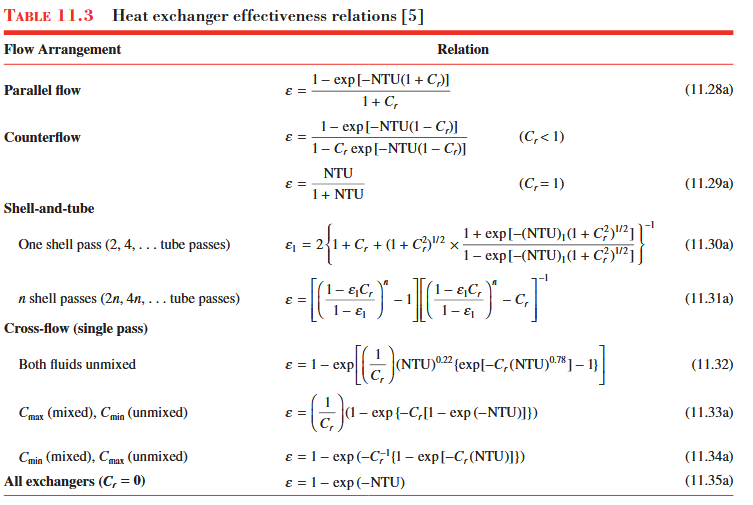

In this example (effectiveness_shell_and_tube method), we use expression 11.30a.

$$
\varepsilon =
\frac{2}
{
1 + C_r + \sqrt{1 + C_r^2}
\;
\frac{1 + \exp\left[-NTU\sqrt{1 + C_r^2}\right]}
{1 - \exp\left[-NTU\sqrt{1 + C_r^2}\right]}
}
$$

In [2]:
def lmtd(deltaT1, deltaT2, eps=1e-12):
    """Log-mean temperature difference"""
    deltaT1 = float(deltaT1)
    deltaT2 = float(deltaT2)
    if abs(deltaT1 - deltaT2) < 1e-9:
        return 0.5*(deltaT1 + deltaT2)
    # prevent log of negative or zero
    if deltaT1*deltaT2 <= 0:
        raise ValueError(f"LMTD requires deltaT1 and deltaT2 to have same sign. Got {deltaT1=}, {deltaT2=}")
    return (deltaT1 - deltaT2) / math.log((deltaT1 + eps)/(deltaT2 + eps))

def effectiveness_shell_and_tube(NTU, Cr):
    """
    Effectiveness for a shell-and-tube heat exchanger
    with one shell pass (and any even number of tube passes). Relationship 11.30a
    """
    NTU = float(NTU)
    Cr = float(Cr)

    # Special case: Cr -> 1 limit
    if abs(1 - Cr) < 1e-12:
        return NTU / (1 + NTU)

    # Common term
    sqrt_term = math.sqrt(1 + Cr**2)
    exp_term = math.exp(-NTU * sqrt_term)

    epsilon = 2 / (
        1 + Cr + sqrt_term * ((1 + exp_term) / (1 - exp_term))
    )

    return epsilon

def epsilon_NTU_outlets(UA, mh, cph, Th_in, mc, cpc, Tc_in, arrangement="shell_and_tube"):
    """Compute Q, ε, NTU, and outlet temps using ε–NTU."""
    Ch = mh*cph
    Cc = mc*cpc
    Cmin = min(Ch, Cc)
    Cmax = max(Ch, Cc)
    Cr = Cmin/Cmax if Cmax > 0 else 0.0
    NTU = UA/Cmin if Cmin > 0 else 0.0

    if arrangement.lower() == "shell_and_tube":
        eps = effectiveness_shell_and_tube(NTU, Cr)
    else:
        raise NotImplementedError("Only shell_and_tube is implemented in this teaching notebook.")

    Qmax = Cmin*(Th_in - Tc_in)
    Q = eps*Qmax

    Th_out = Th_in - Q/Ch
    Tc_out = Tc_in + Q/Cc

    return {
        "Q": Q,
        "epsilon": eps,
        "NTU": NTU,
        "Cr": Cr,
        "Th_out": Th_out,
        "Tc_out": Tc_out,
        "Ch": Ch,
        "Cc": Cc,
        "Cmin": Cmin,
        "Qmax": Qmax,
    }


## 2. Estimating the overall heat transfer coefficient U

### Review

Rememeber from the **Intro to Convection and Heat Exchangers** notes, we modeled heat transfer between two fluids seperated by a wall using **equivalent resistances** and **overall heat transfer coefficient**.
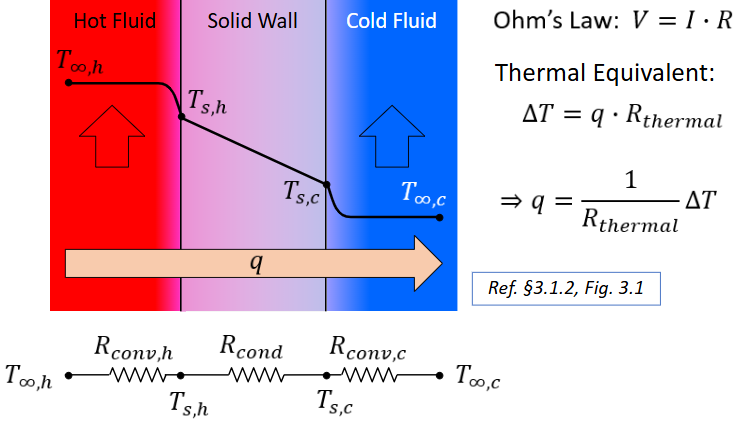 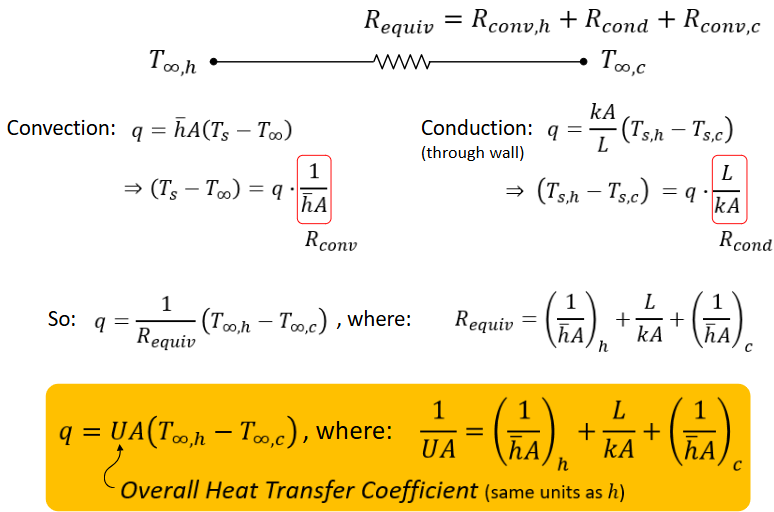


Now we use the same idea to get the **overall heat transfer coefficient based on the outside surface area** for the shell-and-tube design, while also including terms for inner and outter fouling. 


$$
\frac{1}{U_o}
=
\underbrace{\frac{1}{h_o}}_{\text{outer convection}}
+
\underbrace{R_{f,o}}_{\text{outer fouling}}
+
\underbrace{\frac{\Delta r}{k_w}}_{\text{wall conduction}}
+
\underbrace{R_{f,i}\frac{A_o}{A_i}}_{\text{inner fouling (area adjusted)}}
+
\underbrace{\frac{A_o}{h_i A_i}}_{\text{inner convection (area adjusted)}}
$$

Each term represents a physical layer that heat must cross:

- Inner convection resistance  
- Inner fouling resistance  
- Tube wall conduction resistance  
- Outer fouling resistance  
- Outer convection resistance  


### What Is Known vs. What Must Be Modeled

**Given:**
- Geometry: $D_i, D_o, L, N$ → determines $A_i, A_o, \Delta r$
- Wall conductivity: $k_w$
- Fouling factors: $R_{f,i}, R_{f,o}$

Once geometry and materials are specified, these terms are fixed.

**Unknown (must be modeled):**

$$
h_i \quad \text{and} \quad h_o
$$

These depend on flow conditions and correlations:

$$
h_i = f(Re_i, Pr_i), 
\qquad
h_o = f(Re_o, Pr_o)
$$

--- 

### Nusselt Number
To get the $h$ values, we need to find $Nu$, which is basically a nondimensional $h$ value. There are many empirical expressions for $Nu$, given different conditions. A few are listed below:

#### Dittus–Boelter Correlation

Used for turbulent flow in smooth tubes.

$$
Nu = 0.023 \, Re^{0.8} \, Pr^{n}
$$

where

- $n = 0.4$ for heating of the fluid  
- $n = 0.3$ for cooling of the fluid  

Validity (approximate):

- $Re \gtrsim 10^4$
- $0.7 \lesssim Pr \lesssim 160$
- Fully developed turbulent flow
- Smooth circular tubes

## Gnielinski Correlation

More accurate turbulent internal flow correlation:

$$
Nu =
\frac{(f/8)(Re - 1000)Pr}
{1 + 12.7\sqrt{f/8}\left(Pr^{2/3} - 1\right)}
$$

where the Darcy friction factor $f$ can be estimated for smooth tubes as:

$$
f = (0.79 \ln Re - 1.64)^{-2}
$$

Validity (approximate):

- $3000 \lesssim Re \lesssim 5 \times 10^6$
- $0.5 \lesssim Pr \lesssim 2000$
- Fully developed turbulent flow
- Circular tubes

---
Here, we use the Gnielinski Correlation. Then, we get the values for $h$ using:

$$
h = \frac{(Nu) \, k}{D}
$$

Note: There is a $Nu$ and $h$ for each solid-fluid interface (two in this case).

In [3]:
def prandtl(mu, cp, k):
    return mu*cp/k

def friction_factor_haaland(Re, e_over_D):
    """Darcy friction factor using Haaland approximation (turbulent)."""
    Re = float(Re)
    if Re <= 0:
        raise ValueError("Re must be positive")
    # Avoid invalid values
    term = (e_over_D/3.7)**1.11 + 6.9/Re
    return ( -1.8*math.log10(term) )**-2

def nu_gnielinski(Re, Pr, f_darcy=None):
    """Gnielinski correlation for turbulent flow in smooth/rough pipes.
    Valid roughly for 3000 < Re < 5e6 and 0.5 < Pr < 2000.
    """
    Re = float(Re)
    Pr = float(Pr)
    if f_darcy is None:
        # smooth-pipe approximation (Petukhov)
        f_darcy = (0.79*math.log(Re) - 1.64)**-2
    f = float(f_darcy)
    return (f/8)*(Re - 1000)*Pr / (1 + 12.7*math.sqrt(f/8)*(Pr**(2/3) - 1))

def hi_tube_side(m_dot, rho, mu, cp, k, D_i, A_flow, eps_abs=0.0):
    """Tube-side h_i using Gnielinski."""
    V = m_dot/(rho*A_flow)
    Re = rho*V*D_i/mu
    Pr = prandtl(mu, cp, k)
    e_over_D = (eps_abs/D_i) if D_i > 0 else 0.0
    f = friction_factor_haaland(Re, e_over_D) if Re > 2300 else 64.0/Re
    Nu = nu_gnielinski(Re, Pr, f_darcy=f) if Re > 3000 else 3.66
    h = Nu*k/D_i
    return h, Re, Pr, f, Nu, V

def ho_shell_side_tubebank(Vmax, rho, mu, cp, k, D_o, C=0.27, n=0.63, correction=0.6):
    """Shell-side h_o using a simple tube-bank crossflow correlation: Nu = C Re^n Pr^(1/3).
    The notes recommend a conservative correction factor (~0.6) for real shell-side non-idealities.
    """
    Re = rho*Vmax*D_o/mu
    Pr = prandtl(mu, cp, k)
    Nu = C*(Re**n)*(Pr**(1/3))
    h_ideal = Nu*k/D_o
    return correction*h_ideal, Re, Pr, Nu, h_ideal

def overall_Uo(hi, ho, Do, Di, kw, Rfo=0.0, Rfi=0.0):
    """Overall U based on outside area. Simplified cylindrical-wall resistance.
    1/Uo = 1/ho + Rfo + (Do*ln(Do/Di))/(2*kw) + (Do/Di)*(1/hi + Rfi)
    """
    if Di <= 0 or Do <= 0:
        raise ValueError("Di and Do must be > 0")
    wall = (Do*math.log(Do/Di))/(2*kw) if kw > 0 else 0.0
    return 1.0/( (1/ho) + Rfo + wall + (Do/Di)*((1/hi) + Rfi) )


---
## 3. Example: A compact shell-and-tube heat exchanger

1) pick geometry (tube diameters, length, number of tubes)
2) choose fluid properties (constant)
3) compute $h_i$, $h_o$, then $U$
4) compute $UA$, then outlets with ε–NTU

In [4]:
@dataclass
class TubeBundle:
    N_tubes: int
    L: float        # tube length [m]
    Di: float       # tube inner diameter [m]
    Do: float       # tube outer diameter [m]
    kw: float       # tube wall conductivity [W/mK]

    @property
    def Ai_total(self):
        return self.N_tubes*math.pi*self.Di*self.L

    @property
    def Ao_total(self):
        return self.N_tubes*math.pi*self.Do*self.L

    @property
    def Aflow_total(self):
        return self.N_tubes*math.pi*(self.Di**2)/4

bundle = TubeBundle(
    N_tubes=100,
    L=3.0,
    Di=0.016,
    Do=0.019,
    kw=16.0,   # stainless-ish
)

bundle.Ao_total, bundle.Aflow_total

(17.907078125461823, 0.020106192982974676)

In [5]:
# --- Fluid properties (constant property) ---
# Hot side (tube side): water-like
hot = dict(rho=995.0, mu=0.0007, cp=4180.0, k=0.62)
# Cold side (shell side): water-like (could be different fluid)
cold = dict(rho=997.0, mu=0.0009, cp=4180.0, k=0.60)

# --- Operating conditions ---
mh = 0.8   # kg/s (tube side)
mc = 1.0   # kg/s (shell side)
Th_in = 80.0
Tc_in = 20.0

# Shell-side crossflow max velocity through tube bank (prescribed)
Vmax_shell = 0.6  # m/s

# Roughness for tube-side friction/h correlation
eps_abs = 1e-5  # m

hi, Re_i, Pr_i, f_i, Nu_i, V_i = hi_tube_side(
    m_dot=mh,
    rho=hot["rho"], mu=hot["mu"], cp=hot["cp"], k=hot["k"],
    D_i=bundle.Di,
    A_flow=bundle.Aflow_total,
    eps_abs=eps_abs,
)

ho, Re_o, Pr_o, Nu_o, ho_ideal = ho_shell_side_tubebank(
    Vmax=Vmax_shell,
    rho=cold["rho"], mu=cold["mu"], cp=cold["cp"], k=cold["k"],
    D_o=bundle.Do,
    C=0.27, n=0.63,
    correction=0.6,
)

Uo = overall_Uo(hi=hi, ho=ho, Do=bundle.Do, Di=bundle.Di, kw=bundle.kw, Rfo=0.0, Rfi=0.0)
UA = Uo*bundle.Ao_total

hi, ho, Uo, UA

(141.82500000000002,
 3618.4596661973997,
 114.26754032296421,
 2046.1977717676791)

The tube-side heat transfer coefficient is much smaller than the shell-side value, so the tube side dominates the overall resistance. As a result, the overall heat transfer coefficient is close to the tube-side value

In [6]:
res = epsilon_NTU_outlets(UA, mh, hot["cp"], Th_in, mc, cold["cp"], Tc_in)
res

{'Q': 76666.95588820036,
 'epsilon': 0.38211202097388536,
 'NTU': 0.6119012475381815,
 'Cr': 0.8,
 'Th_out': 57.07327874156688,
 'Tc_out': 38.3413770067465,
 'Ch': 3344.0,
 'Cc': 4180.0,
 'Cmin': 3344.0,
 'Qmax': 200640.0}

### Interpreting results
- $Re_i$ indicates whether tube-side flow is turbulent (good for heat transfer).
- $h_i$ and $h_o$ show which side dominates the thermal resistance.
- $U A$ collapses all geometry + convection into a single number that plugs right into ε–NTU.

In [7]:
def report(bundle, hi, ho, Uo, UA, res, Re_i, Re_o, Nu_i, Nu_o):
    print("--- Heat Exchanger Report ---")
    print(f"Tubes: N={bundle.N_tubes}, L={bundle.L:.2f} m, Di={bundle.Di:.4f} m, Do={bundle.Do:.4f} m")
    print(f"Areas: Ao_total={bundle.Ao_total:.2f} m^2, Ai_total={bundle.Ai_total:.2f} m^2")
    print(f"Tube-side: Re={Re_i:.2e}, Nu={Nu_i:.2f}, hi={hi:.0f} W/m^2K")
    print(f"Shell-side: Re={Re_o:.2e}, Nu={Nu_o:.2f}, ho={ho:.0f} W/m^2K")
    print(f"Overall: Uo={Uo:.1f} W/m^2K, UA={UA:.1f} W/K")
    print("--- ε–NTU outputs ---")
    print(f"NTU={res['NTU']:.2f}, Cr={res['Cr']:.2f}, epsilon={res['epsilon']:.3f}")
    print(f"Q={res['Q']:.0f} W")
    print(f"Th_out={res['Th_out']:.2f} °C, Tc_out={res['Tc_out']:.2f} °C")

report(bundle, hi, ho, Uo, UA, res, Re_i, Re_o, Nu_i, Nu_o)

--- Heat Exchanger Report ---
Tubes: N=100, L=3.00 m, Di=0.0160 m, Do=0.0190 m
Areas: Ao_total=17.91 m^2, Ai_total=15.08 m^2
Tube-side: Re=9.09e+02, Nu=3.66, hi=142 W/m^2K
Shell-side: Re=1.26e+04, Nu=190.97, ho=3618 W/m^2K
Overall: Uo=114.3 W/m^2K, UA=2046.2 W/K
--- ε–NTU outputs ---
NTU=0.61, Cr=0.80, epsilon=0.382
Q=76667 W
Th_out=57.07 °C, Tc_out=38.34 °C


---
## 4. Pressure-drop
Heat exchangers are rarely designed on thermal performance alone: you also have to keep in mind the operating cost of a heat exchanger. The main factor to consider is the **pressure drop**, which drives pumping power and operating cost. The shell-and-tube notes discuss tube and shell side ΔP estimation and why constraints like ΔP ≤ N psi are common.  

The handwritten notes also include a tube-side ΔP form built from friction loss plus minor losses (e.g., elbows/returns).  

Below is a simple tube-side ΔP model:
- Darcy–Weisbach friction loss: $\Delta P_f = f (L/D) (\rho V^2/2)$
- Minor losses: $\Delta P_m = K (\rho V^2/2)$

The **tradeoff**:
- push flow rate up → better h and higher Q
- but ΔP grows roughly like $V^2$


In [8]:
def deltaP_tubeside(rho, V, L, D, f_darcy, K_minor=0.0, n_passes=1):
    dynamic = 0.5*rho*V**2
    dP = n_passes * (f_darcy*(L/D)*dynamic) + K_minor*dynamic
    return dP

# Example: assume a modest total minor-loss coefficient to represent entry/exit + bends
K_minor = 5.0
dP_tube = deltaP_tubeside(hot['rho'], V_i, bundle.L, bundle.Di, f_i, K_minor=K_minor, n_passes=2)
dP_tube

24.971804037025215

---
## 6. Flow-rate tradeoff (Q vs ΔP)

In real design/operation, you often tune flow rates. Here we sweep tube-side $\dot m_h$ and show:
- $Q$ increases
- but tube-side pressure drop also increases

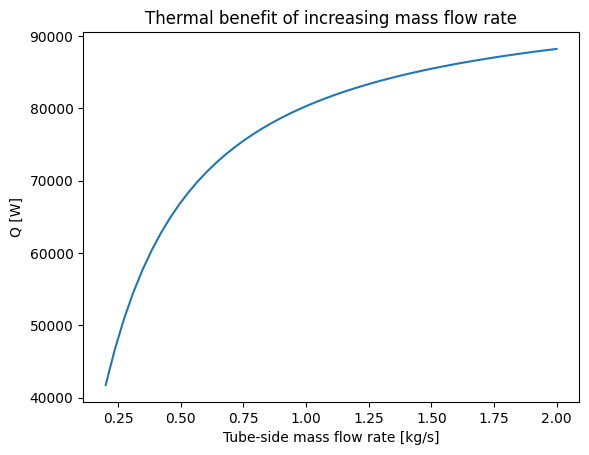

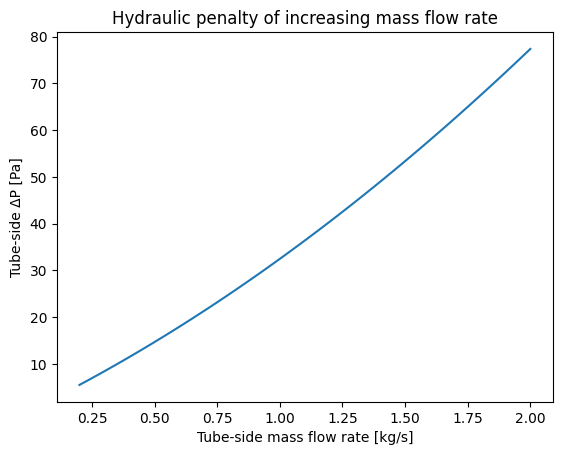

In [12]:
mhs = np.linspace(0.2, 2.0, 50)
Qs = []
dPs = []

for mh_try in mhs:
    # recompute hi, U, UA for each mh (since Re changes)
    hi_try, Re_i_try, Pr_i_try, f_i_try, Nu_i_try, V_i_try = hi_tube_side(
        m_dot=mh_try,
        rho=hot["rho"], mu=hot["mu"], cp=hot["cp"], k=hot["k"],
        D_i=bundle.Di,
        A_flow=bundle.Aflow_total,
        eps_abs=eps_abs,
    )
    Uo_try = overall_Uo(hi=hi_try, ho=ho, Do=bundle.Do, Di=bundle.Di, kw=bundle.kw)
    UA_try = Uo_try*bundle.Ao_total

    res_try = epsilon_NTU_outlets(UA_try, mh_try, hot['cp'], Th_in, mc, cold['cp'], Tc_in)
    Qs.append(res_try['Q'])

    dP_try = deltaP_tubeside(hot['rho'], V_i_try, bundle.L, bundle.Di, f_i_try, K_minor=K_minor, n_passes=2)
    dPs.append(dP_try)

Qs = np.array(Qs)
dPs = np.array(dPs)

plt.figure()
plt.plot(mhs, Qs)
plt.xlabel('Tube-side mass flow rate [kg/s]')
plt.ylabel('Q [W]')
plt.title('Thermal benefit of increasing mass flow rate')
plt.show()

plt.figure()
plt.plot(mhs, dPs)
plt.xlabel('Tube-side mass flow rate [kg/s]')
plt.ylabel('Tube-side ΔP [Pa]')
plt.title('Hydraulic penalty of increasing mass flow rate')
plt.show()


## Summary
$$
\text{Geometry + Flow}
\;\longrightarrow\;
h_i,\; h_o
$$

$$
h_i,\; h_o
\;\longrightarrow\;
U
$$

$$
U + A
\;\longrightarrow\;
UA
$$

$$
UA
\;\longrightarrow\;
NTU = \frac{UA}{C_{\min}}
$$

$$
NTU + C_r
\;\longrightarrow\;
\varepsilon
$$

$$
\varepsilon + Q_{\max}
\;\longrightarrow\;
Q
$$